Best K: 19
              precision    recall  f1-score   support

           0       0.85      0.73      0.78       100
           1       0.60      0.76      0.67        54

    accuracy                           0.74       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.74      0.75       154



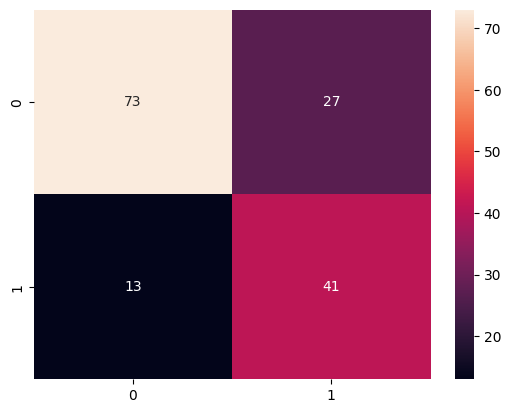

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Dataset yuklash
URL = 'https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv'
df = pd.read_csv(URL)

# Shovqinli ustunlarni tashlaymiz
df = df.drop(['BloodPressure', 'SkinThickness'], axis=1)

# X va y ajratamiz
x = df.drop('Outcome', axis=1)
y = df['Outcome']

# 1. Train/Test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=77, stratify=y
)

# 2. 0 larni NaN ga o'tkazamiz
cols = ['Glucose', 'Insulin', 'BMI']
x_train[cols] = x_train[cols].replace(0, np.nan)
x_test[cols] = x_test[cols].replace(0, np.nan)

# 3. NaN larni median bilan to'ldiramiz
imputer = SimpleImputer(strategy="median")
x_train = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame(imputer.transform(x_test), columns=x_test.columns)

# 4. SMOTE - faqat x_train ga
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

# 5. Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 6. Eng yaxshi K ni topish
scores = []
for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, x_train, y_train, cv=5, scoring='f1')
    scores.append(score.mean())

best_k = np.argmax(scores) + 1
print("Best K:", best_k)

# 7. Final model
knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_model.fit(x_train, y_train)
y_pred = knn_model.predict(x_test)

# 8. Baholash
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g')
plt.show()